In [1]:
import io
import textwrap

import beaker
import faceted
import numpy as np
import pandas as pd
import xarray as xr

import plotting
import utils

In [2]:
def open_beaker_dataset(dataset_id: str, path: str) -> xr.Dataset:
    """Given a beaker dataset ID and path within dataset, return an xarray
    dataset.

    Note: dataset must fit in memory. Requires h5netcdf backend.  Adapted from
    ace2-paper repo.
    """
    client = beaker.Beaker.from_env()
    file = client.dataset.get_file(dataset_id, path)
    ds = xr.open_dataset(io.BytesIO(file), engine="h5netcdf").load()
    if "source" in ds.dims:
        ds = ds.sel(source="target").drop_vars("source")
    return ds


def open_precombined_datasets(cases: dict[str, str], path: str) -> xr.Dataset:
    datasets = {}
    for case, dataset_id in cases.items():
        ds = open_beaker_dataset(dataset_id, path)
        ds = ds.assign_coords(sample=range(1, ds.sizes["sample"] + 1))
        datasets[case] = ds
    return xr.concat(datasets.values(), dim=pd.Index(cases.keys(), name="model"))


def open_data_only_datasets(precombined_cases: dict[str, str], path: str) -> xr.Dataset:
    # Even though we did not train on AMIP constant CO2 in any configuration,
    # this is just how we split the data-only inference jobs.
    train_and_validate = open_precombined_datasets(precombined_cases, f"train-and-validate/{path}")
    test = open_precombined_datasets(precombined_cases, f"test/{path}")
    return xr.concat([train_and_validate, test], dim="year").squeeze("sample")

def open_ace_datasets(precombined_cases: dict[str, str], path: str) -> xr.Dataset:
    main = open_precombined_datasets(precombined_cases, f"main/{path}")
    return main.squeeze("sample")

In [3]:
TEMPLATE = "2026-09-09-{model}-amip-constant-CO2-inference"

DATA_ONLY_DATASETS = {
    "SHiELD": utils.beaker_dataset_id_from_name("2026-03-24-split-amip-constant-CO2-data-only-evaluator"),
    "SHiELD-historical-co2": utils.beaker_dataset_id_from_name("2026-03-24-amip-ic_0001-split-data-only-evaluator"),
}
ACE_DATASETS = {
    "ACE2-SHiELD": utils.beaker_dataset_id_from_name(TEMPLATE.format(model="ACE2-SHiELD")),
    "no-random-co2-energy-conserving-rs0": utils.beaker_dataset_id_from_name(TEMPLATE.format(model="no-random-co2-energy-conserving-rs0")),
    "no-random-co2-energy-conserving-rs1": utils.beaker_dataset_id_from_name(TEMPLATE.format(model="no-random-co2-energy-conserving-rs1")),
    "full-energy-conserving-rs0": utils.beaker_dataset_id_from_name(TEMPLATE.format(model="full-energy-conserving-rs0")),
    "full-energy-conserving-rs1": utils.beaker_dataset_id_from_name(TEMPLATE.format(model="full-energy-conserving-rs1")),
}


/home/spencerc/ace2s-shield-plus-paper/manuscript/.pixi/envs/default/lib/python3.13/site-packages/beaker/util.py:25: RuntimeWarning: Found unknown field 'budget: 01HPM52AQCRXMD5BPZAMJG3TDZ' for data model 'Workspace'. This may be a newly added field that hasn't been defined in beaker-py yet. Please submit an issue report about this here:
https://github.com/allenai/beaker-py/issues/new?assignees=&labels=bug&template=bug_report.yml
  warnings.warn(
/home/spencerc/ace2s-shield-plus-paper/manuscript/.pixi/envs/default/lib/python3.13/site-packages/beaker/util.py:25: RuntimeWarning: Found unknown field 'budget: 01HPM52AQCRXMD5BPZAMJG3TDZ' for data model 'Experiment'. This may be a newly added field that hasn't been defined in beaker-py yet. Please submit an issue report about this here:
https://github.com/allenai/beaker-py/issues/new?assignees=&labels=bug&template=bug_report.yml
  warnings.warn(
/home/spencerc/ace2s-shield-plus-paper/manuscript/.pixi/envs/default/lib/python3.13/site-packages

In [4]:
data_only_ds = open_data_only_datasets(DATA_ONLY_DATASETS, "annual_diagnostics.nc")
ace_ds = open_ace_datasets(ACE_DATASETS, "annual_diagnostics.nc")
ds = xr.concat([data_only_ds, ace_ds], dim="model")

/home/spencerc/ace2s-shield-plus-paper/manuscript/.pixi/envs/default/lib/python3.13/site-packages/beaker/util.py:25: RuntimeWarning: Found unknown field 'budget: 01HPM52AQCRXMD5BPZAMJG3TDZ' for data model 'Dataset'. This may be a newly added field that hasn't been defined in beaker-py yet. Please submit an issue report about this here:
https://github.com/allenai/beaker-py/issues/new?assignees=&labels=bug&template=bug_report.yml
  warnings.warn(


Output()

Output()

Output()

Output()

Output()

Output()

Output()

Output()

Output()

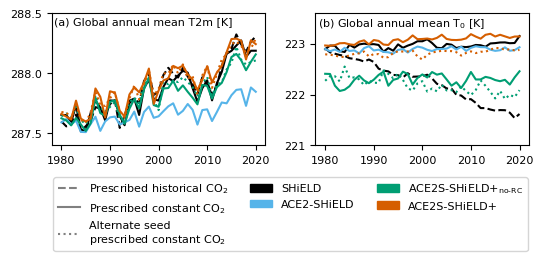

In [5]:
plotting.configure_style(fontsize=8)

MAIN_NO_RC_MODEL = "no-random-co2-energy-conserving-rs0"
ALTERNATE_NO_RC_MODEL = "no-random-co2-energy-conserving-rs1"
MAIN_MODEL = "full-energy-conserving-rs0"
ALTERNATE_MODEL = "full-energy-conserving-rs1"

fig, (ax1, ax2) = faceted.faceted(1, 2, width=5.5, aspect=0.618, sharey=False, internal_pad=0.5, left_pad=0.475, bottom_pad=1.05)

ds.TMP2m.sel(model="SHiELD").plot(ax=ax1, color="k")
ds.TMP2m.sel(model="SHiELD-historical-co2").plot(ax=ax1, color="k", linestyle="--")
ds.TMP2m.sel(model="ACE2-SHiELD").plot(ax=ax1, color="C0")
ds.TMP2m.sel(model=ALTERNATE_NO_RC_MODEL).plot(ax=ax1, color="C2", ls=":")
ds.TMP2m.sel(model=ALTERNATE_MODEL).plot(ax=ax1, color="C4", ls=":")
ds.TMP2m.sel(model=MAIN_NO_RC_MODEL).plot(ax=ax1, color="C2")
ds.TMP2m.sel(model=MAIN_MODEL).plot(ax=ax1, color="C4")

ds.air_temperature_0.sel(model="SHiELD").plot(ax=ax2, color="k", label="SHiELD")
ds.air_temperature_0.sel(model="SHiELD-historical-co2").plot(ax=ax2, color="k", linestyle="--", label=None)
ds.air_temperature_0.sel(model="ACE2-SHiELD").plot(ax=ax2, color="C0", label="ACE2-SHiELD")
ds.air_temperature_0.sel(model=ALTERNATE_NO_RC_MODEL).plot(ax=ax2, color="C2", ls=":")
ds.air_temperature_0.sel(model=ALTERNATE_MODEL).plot(ax=ax2, color="C4", ls=":")
ds.air_temperature_0.sel(model=MAIN_NO_RC_MODEL).plot(ax=ax2, color="C2")
ds.air_temperature_0.sel(model=MAIN_MODEL).plot(ax=ax2, color="C4")

for ax in (ax1, ax2):
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title("")

ax1.set_ylim(287.4, 288.5)
ax2.set_ylim(221, 223.6)

ax1.set_yticks([287.5, 288.0, 288.5])
ax1.set_yticklabels([287.5, 288.0, 288.5])

import matplotlib.lines as mlines
import matplotlib.patches as mpatches


gray_solid = mlines.Line2D(
    [], [], color="gray", linestyle="--", label="Prescribed historical CO$_2$"
)
gray_dashed = mlines.Line2D(
    [], [], color="gray", linestyle="-", label="Prescribed constant CO$_2$"
)
gray_dotted = mlines.Line2D(
    [], [], color="gray", linestyle=":", label="Alternate seed\nprescribed constant CO$_2$"
)

shield_patch = mpatches.Patch(color="k", label="SHiELD")
ace2_shield_patch = mpatches.Patch(color="C0", label="ACE2-SHiELD")
ace2s_shield_w_o_random_co2_patch = mpatches.Patch(color="C2", label="ACE2S-SHiELD+$_{\\text{no-RC}}$")
ace2s_shield_w_random_co2_patch = mpatches.Patch(color="C4", label="ACE2S-SHiELD+")

handles = [gray_solid, gray_dashed, gray_dotted, shield_patch, ace2_shield_patch, ace2s_shield_w_o_random_co2_patch, ace2s_shield_w_random_co2_patch]
labels = ["Prescribed historical CO$_2$", "Prescribed constant CO$_2$", "Alternate seed\nprescribed constant CO$_2$", "SHiELD", "ACE2-SHiELD", "ACE2S-SHiELD+$_{\\text{no-RC}}$", "ACE2S-SHiELD+"]

central_x_position = plotting.get_central_position_between_axes((ax1, ax2), "x")
fig.legend(
    handles=handles,
    labels=labels,
    loc="upper center",
    bbox_to_anchor=(central_x_position, 0.3),
    ncol=3,
    frameon=True
)

ax1.annotate(
    "(a) Global annual mean T2m [K]",
    xy=(0, 1),
    xytext=(2, -2),
    va="top",
    xycoords="axes fraction",
    textcoords="offset points",
)
ax2.annotate(
    textwrap.fill("(b) Global annual mean T$_0$ [K]", width=50),
    xy=(0, 1),
    xytext=(2, -2),
    va="top",
    xycoords="axes fraction",
    textcoords="offset points",
)

fig.patch.set_alpha(0)
fig.savefig("figure-06.png", dpi=300)
fig.savefig("figure-06.pdf")
